In [ ]:
# Import python libraries
import osmnx as osm
import geopandas as gpd
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews
import holoviews as hv

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
# Look for metro features to address
metro_gdf = osm.features_from_address(
("Metropolitan State University of Denver, Denver, CO, United States"),
{'amenity':['university']}
)
metro_gdf

addr:city addr:housenumber addr:postcode addr:state  \
element_type osmid                                                             
node         2155391509     Denver              890         80204         CO   
             5336796189     Denver             1201         80202         CO   
             12187139864    Denver              800         80204         CO   
             12187139865    Denver             1201         80204         CO   
way          50807585       Denver             1201         80204         CO   

                              addr:street        alt_name     amenity  \
element_type osmid                                                      
node         2155391509   Auraria Parkway      MSU Denver  university   
             5336796189       16th Street             NaN  university   
             12187139864    Curtis Street             NaN  university   
             12187139865   Larimer Street             NaN  university   
way          50807585          5th Street  Auraria Campus  university   

                         designation                                     name  \
element_type osmid                                                              
node         2155391509   University  Metropolitan State University of Denver   
             5336796189          NaN                University of the Rockies   
             12187139864         NaN              Community College of Denver   
             12187139865         NaN            University of Colorado Denver   
way          50807585            NaN          Auraria Higher Education Center   

                                                      old_name  ...  \
element_type osmid                                              ...   
node         2155391509   Metropolitan State College of Denver  ...   
             5336796189                                    NaN  ...   
             12187139864                                   NaN  ...   
             12187139865                                   NaN  ...   
way          50807585                                      NaN  ...   

                                                                   geometry  \
element_type osmid                                                            
node         2155391509                         POINT (-105.00774 39.74507)   
             5336796189                         POINT (-104.99685 39.74918)   
             12187139864                        POINT (-105.00461 39.74126)   
             12187139865                        POINT (-105.00177 39.74607)   
way          50807585     POLYGON ((-105.00160 39.74647, -105.00159 39.7...   

                         addr:unit operator:type  \
element_type osmid                                 
node         2155391509        NaN           NaN   
             5336796189        200           NaN   
             12187139864       NaN        public   
             12187139865       NaN           NaN   
way          50807585          NaN           NaN   

                                                                      nodes  \
element_type osmid                                                            
node         2155391509                                                 NaN   
             5336796189                                                 NaN   
             12187139864                                                NaN   
             12187139865                                                NaN   
way          50807585     [647873186, 12141206105, 3273383408, 501534305...   

                           ele gnis:feature_id internet_access  \
element_type osmid                                               
node         2155391509    NaN             NaN             NaN   
             5336796189    NaN             NaN             NaN   
             12187139864   NaN             NaN             NaN   
             12187139865   NaN             NaN             NaN   
way          5080

<Axes: >

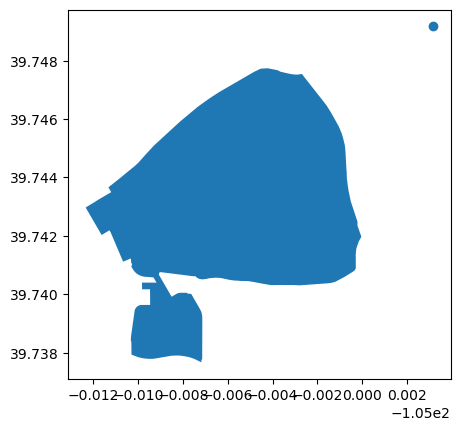

In [5]:
metro_gdf.plot()

In [7]:
auraria = metro_gdf [metro_gdf.alt_name=="Auraria Campus"]

In [10]:
# Plot MSU boundary
MSU_map = auraria.reset_index().hvplot(
#map title
title="Metropolitan University of Denver, Denver, CO" , 
#add a basemap
geo=True, tiles='EsriImagery',
# change colors
fill_color='black', fill_alpha=0.2,
line_color='red', line_width=5,
#change the image size 
frame_width=400, frame_height=400,
text_color='gray')
hv.save(MSU_map, 'MSU.html')
MSU_map

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]